In [23]:
import os 
from dotenv import load_dotenv

load_dotenv()
 


os.environ["OPENROUTER_API_KEY"] = os.getenv("OPENROUTER_API_KEY")

from langchain_aws import BedrockLLM
import  boto3

bedrock = boto3.client(service_name="bedrock-runtime",region_name="us-east-1")

llm = BedrockLLM(model="meta.llama3-70b-instruct-v1:0",client=bedrock)

In [24]:
from langchain.agents import create_agent 
from  langchain_groq import ChatGroq
from pydantic import BaseModel ,Field
from langchain.chat_models import init_chat_model


In [25]:
llm = ChatGroq(model="llama-3.3-70b-versatile")
#llm = init_chat_model("google_genai:gemini-3.1-flash-lite")

## Agent Orchestrator
    - FIRST PHASE: 
        1 planner agent     # Done 
        2 coding agent  #done 
        3 file system tools  # Done 
        4 Terminal tools #Done 
        5 Browser agent #Done 
        6 Debug agent #Done 
        7 Deployment agent 
    - SECOND PHASE 
        1 Researcher agent 
        2 Memory agent 
        

## Login with google  or other authentication  
## Guardrials 
## security

##  planner_agent.py 

In [26]:
from typing import Dict, Any , List

from pydantic import BaseModel , Field
class PlannerOutput(BaseModel):
    project_name: str = Field(description="Short slug-style project name, e.g. 'todo-app'")
    tech_stack: Dict[str, Any] = Field(
        description="Dict with keys 'backend', 'frontend', 'database'"
    )
    features: List[str] = Field(description="Bullet-list of user-visible features")
    description: str = Field(description="One-paragraph description of the project")


class FileSpec(BaseModel):
    path: str = Field(description="Relative file path, e.g. 'backend/main.py'")
    responsibility: str = Field(description="Single sentence: the ONE thing this file owns")
    imports_from: List[str] = Field(
        default_factory=list,
        description="Paths of other project files this file imports from",
    )


class ProjectManifest(BaseModel):
    project_name: str
    files: List[FileSpec]
    entrypoint: str = Field(
        description="The single file that starts the whole app, e.g. 'backend/main.py'"
    )
    run_command: str = Field(
        description="Shell command to start the app after installing deps, "
                    "e.g. 'uvicorn backend.main:app --reload'"
    )
    install_command: str = Field(
        description="Dependency install command, e.g. 'pip install -r requirements.txt'"
    )


class GeneratedFile(BaseModel):
    path: str = Field(description="Relative file path")
    content: str = Field(description="Complete, production-ready source code for this file")


## PLANNER AGENT 

In [27]:
from langchain_core.prompts import ChatPromptTemplate

PLANNER_PROMPT = ChatPromptTemplate.from_template(
    """You are a senior software architect. Given the user's project description,
produce a structured plan.

RULES:
- Carefully analyze the user's request to determine the required tech stack.
- If the user specifies a tech stack, strictly adhere to it.
- If the user DOES NOT explicitly request a database, DO NOT include a database in the architecture (use simple in-memory data structures or mock data instead).
- Keep the project minimal but fully runnable.

User request:
{query}
"""
)

def planner_agent(query: str) -> PlannerOutput:
    print("\n[1/4] Planner Agent running...")
    chain = PLANNER_PROMPT | llm.with_structured_output(PlannerOutput)
    result = chain.invoke({"query": query})
    print(f"     Project  : {result.project_name}")
    print(f"     Stack    : {result.tech_stack}")
    print(f"     Features : {len(result.features)} features")
    return result

## Architect Agent

In [28]:
from langchain_core.output_parsers import PydanticOutputParser

class GeneratedFile(BaseModel):
    path: str = Field(description="The relative file path (e.g., 'backend/app/main.py')")
    content: str = Field(description="The complete, un-truncated, production-ready source code for this file.")


class FileSpec(BaseModel):
    path: str
    responsibility: str = Field(description="The ONE thing this file owns")
    imports_from: List[str] = Field(default_factory=list)

class ProjectManifest(BaseModel):
    project_name: str
    files: List[FileSpec]
    entrypoint: str = Field(description="The single file path that starts the whole app, e.g. 'backend/app.py'")

You are a Principal Software Architect. Given the following cleaned project specification, break down the entire codebase 
into a flat list of individual file paths needed to make this fully functional.
Do not skip configuration files, router files, database models, or frontend pages.

IMPORTANT
-Make 20 files

Tech Stack:
- Frontend: HTML, CSS ,JAVASCRIPT
- Backend: FastAPI, Python,FLASK 

Cleaned Specification:
{cleaned_spec}

In [29]:
from langchain_core.prompts import ChatPromptTemplate
ARCHITECT_PROMPT = ChatPromptTemplate.from_template(
    """You are a Principal Software Architect. Given the project specification below,
produce the COMPLETE file manifest for a fully runnable project.

CRITICAL RULES:
1. Follow the exact tech stack specified in the project plan.
2. If the plan does NOT include a database, DO NOT generate any database setup, ORM, or migration files.
3. Every entity or core logic should be well-organized into separate files (e.g., routes, services, models) according to the chosen framework's best practices.
4. Include ALL necessary files: source code, frontend assets (if applicable), configuration, requirements/package files, and README.md.
5. Aim for enough files to be real but not bloated (typically 5-15 files).
6. The app must run with a single main command (e.g., `npm start`, `python main.py`, `uvicorn ...`).

Specification:
{spec}
"""
)
    
def architect_agent(plan: PlannerOutput) -> ProjectManifest:
    print("\n[2/4] Architect Agent running...")
    spec_text = (
        f"Project: {plan.project_name}\n"
        f"Description: {plan.description}\n"
        f"Tech Stack: {plan.tech_stack}\n"
        f"Features:\n" + "\n".join(f"  - {f}" for f in plan.features)
    )
    chain = ARCHITECT_PROMPT | llm.with_structured_output(ProjectManifest)
    result = chain.invoke({"spec": spec_text})
    print(f"     Files planned : {len(result.files)}")
    print(f"     Entrypoint    : {result.entrypoint}")
    print(f"     Run with      : {result.run_command}")
    return result


    

## Coding agent 

In [30]:
CODING_PROMPT = ChatPromptTemplate.from_template(
    """You are a Senior Full-Stack Engineer. Write the COMPLETE source code for the file
described below. The code must be production-ready and immediately executable.

=========================================================
PROJECT OVERVIEW
=========================================================
{project_overview}

=========================================================
ALL FILES IN THE PROJECT
=========================================================
{all_files}

=========================================================
ALREADY GENERATED FILES (for context)
=========================================================
{context_files}

=========================================================
FILE TO WRITE NOW
=========================================================
Path        : {file_path}
Responsibility: {responsibility}
May import from: {imports_from}

=========================================================
STRICT RULES
=========================================================
- Return ONLY the raw source code - no markdown fences (no backtick blocks), no explanations.
- The code must be complete and runnable - no placeholders, no TODOs, no ellipsis.
- Use type hints/types, proper docstrings/comments, and error handling.
- For dependency files (e.g., requirements.txt, package.json): list required packages accurately based on the stack.
- For README.md: include setup, install, and run instructions.
- If no database was requested, DO NOT use a database (use in-memory lists/dicts or mocks).
- Ensure cross-origin requests (CORS) are properly handled if separating frontend and backend.
- CRITICAL: The entrypoint file (e.g., app.py, main.py, index.js) MUST explicitly import and register all routes, blueprints, or controllers. Do not just import the file; you must actively register the routes with the application instance to prevent 404 errors.
- CRITICAL: Ensure exact naming consistency for functions, variables, and models across imported files.
"""
)

def coding_agent(manifest: ProjectManifest, plan: PlannerOutput) -> List[GeneratedFile]:
    print(f"\n[3/4] Coding Agent generating {len(manifest.files)} files...")
    project_overview = (
        f"Project: {manifest.project_name}\n"
        f"Description: {plan.description}\n"
        f"Tech Stack: {plan.tech_stack}\n"
        f"Entrypoint: {manifest.entrypoint}\n"
        f"Run: {manifest.run_command}"
    )
    all_files_txt = "\n".join(
        f"  {f.path}  ->  {f.responsibility}" for f in manifest.files
    )

    generated: List[GeneratedFile] = []
    for i, file_spec in enumerate(manifest.files, 1):
        print(f"     [{i:02d}/{len(manifest.files):02d}] Generating {file_spec.path} ...", end=" ", flush=True)
        
        
        context_files = ""
        for gf in generated:
            if gf.path in file_spec.imports_from or any(dep in gf.path for dep in file_spec.imports_from):
                context_files += f"\n--- {gf.path} ---\n{gf.content}\n"
        if not context_files:
            context_files = "(No dependencies generated yet or no dependencies specified.)"

        try:
            response = (CODING_PROMPT | llm).invoke(
                {
                    "project_overview": project_overview,
                    "all_files": all_files_txt,
                    "context_files": context_files,
                    "file_path": file_spec.path,
                    "responsibility": file_spec.responsibility,
                    "imports_from": ", ".join(file_spec.imports_from) or "none",
                }
            )
            content = response.content.strip()
          
            if content.startswith("```"):
                lines = content.splitlines()
                content = "\n".join(lines[1:-1]) if lines[-1].strip() == "```" else "\n".join(lines[1:])
            generated.append(GeneratedFile(path=file_spec.path, content=content))
            print("OK")
        except Exception as exc:
            print(f"FAILED  ({exc})")
            generated.append(GeneratedFile(path=file_spec.path, content=f"# Generation failed: {exc}\n"))
    return generated

DEBUGGER AGENT 

In [31]:
DEBUGGER_PROMPT = ChatPromptTemplate.from_template(
    """You are a Principal Software Engineer with 20+ years of experience.
You are acting as an autonomous Debugger Agent.

=========================================================
PROJECT STRUCTURE
=========================================================
{project_structure}

=========================================================
CURRENT FILE
=========================================================
Path: {file_path}

=========================================================
GENERATED SOURCE CODE
=========================================================
{code}

=========================================================
YOUR TASK
=========================================================
Review the code above and fix ALL issues including:
- Syntax errors                - Import errors / missing imports
- Circular imports             - Undefined variables or functions
- Incorrect API usage          - Runtime exceptions
- Logic bugs                   - Framework/Library misuse
- Missing CORS headers         - Security issues
- Async/Await mistakes         - Data persistence issues (if DB is used)

Also improve: exception handling, type hints, logging, structure.

=========================================================
STRICT RULES
=========================================================
- Return ONLY the corrected source code. NO markdown fences. NO explanations.
- Do NOT truncate. Return the COMPLETE file.
- Do NOT add TODO comments or placeholders.
- PRESERVE all existing functionality.
- If the file is already correct, return it as-is.
"""
)

def debugger_agent(generated_files: List[GeneratedFile]) -> List[GeneratedFile]:
    print(f"\n[4/4] Debugger Agent reviewing {len(generated_files)} files...")
    project_structure = "\n".join(f"  {f.path}" for f in generated_files)
    chain = DEBUGGER_PROMPT | llm
    fixed: List[GeneratedFile] = []
    for i, gf in enumerate(generated_files, 1):
        print(f"     [{i:02d}/{len(generated_files):02d}] Debugging {gf.path} ...", end=" ", flush=True)
        try:
            response = chain.invoke(
                {
                    "project_structure": project_structure,
                    "file_path": gf.path,
                    "code": gf.content,
                }
            )
            content = response.content.strip()
            if content.startswith("```"):
                lines = content.splitlines()
                content = "\n".join(lines[1:-1]) if lines[-1].strip() == "```" else "\n".join(lines[1:])
            fixed.append(GeneratedFile(path=gf.path, content=content))
            print("OK")
        except Exception as exc:
            print(f"FAILED (keeping original -- {exc})")
            fixed.append(gf)
    return fixed


## TERMINAL AGENT 

In [32]:
import subprocess

def terminal_agent(project_path: str, install_command: str) -> dict:
    """
    Runs inside the generated project folder:
    1. pip install -r requirements.txt
    2. python -m py_compile on every .py file
    Returns a dict with success, executed_commands, stdout, stderr, exit_code.
    """
    print(f"\n[5/5] Terminal Agent running in '{project_path}'...")
    root = Path(project_path)
    commands: list = []
    stdout_logs: list = []
    stderr_logs: list = []
    final_exit_code = 0


    if (root / "requirements.txt").exists():
        commands.append(install_command)
    else:
        print("     WARNING: requirements.txt not found, skipping install")

  
    py_files = list(root.rglob("*.py"))
    if py_files:
        relative_paths = " ".join(str(p.relative_to(root)) for p in py_files)
        commands.append(f"python -m py_compile {relative_paths}")

    for command in commands:
        print(f"     $ {command}")
        try:
            result = subprocess.run(
                command,
                cwd=str(root),
                shell=True,
                capture_output=True,
                text=True,
                timeout=120,
            )
            stdout_logs.append(f"\n===== {command} =====\n{result.stdout}")
            stderr_logs.append(f"\n===== {command} =====\n{result.stderr}")
            if result.returncode != 0:
                final_exit_code = result.returncode
                print(f"     FAILED (exit {result.returncode})")
                if result.stderr:
                    print(f"     {result.stderr[:300]}")
            else:
                print("     OK")
        except subprocess.TimeoutExpired:
            stderr_logs.append(f"\n===== {command} =====\nTIMEOUT")
            final_exit_code = -1
            print("     TIMEOUT")
        except Exception as exc:
            stderr_logs.append(f"\n===== {command} =====\n{exc}")
            final_exit_code = -1
            print(f"     ERROR: {exc}")

    result_dict = {
        "success": final_exit_code == 0,
        "executed_commands": commands,
        "stdout": "\n".join(stdout_logs),
        "stderr": "\n".join(stderr_logs),
        "exit_code": final_exit_code,
    }
    if result_dict["success"]:
        print("     All checks passed!")
    else:
        print("     Some checks failed - see stderr above")
    return result_dict



## save the project 

In [33]:
import zipfile
from pathlib import Path

def save_project(
    files: List[GeneratedFile],
    manifest: ProjectManifest,
    root: str = "generated_project",
) -> Path:
    root_path = Path(root)
    root_path.mkdir(parents=True, exist_ok=True)

    for gf in files:
        full_path = root_path / gf.path
        full_path.parent.mkdir(parents=True, exist_ok=True)
        full_path.write_text(gf.content, encoding="utf-8")

    
    setup_md = (
        f"# {manifest.project_name}\n\n"
        f"## Setup\n\n"
        f"```bash\n"
        f"cd {root}\n"
        f"{manifest.install_command}\n"
        f"```\n\n"
        f"## Run\n\n"
        f"```bash\n"
        f"{manifest.run_command}\n"
        f"```\n\n"
        f"## Entrypoint\n"
        f"`{manifest.entrypoint}`\n"
    )
    (root_path / "SETUP.md").write_text(setup_md, encoding="utf-8")

   
    zip_path = Path(root + ".zip")
    with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as zf:
        for gf in files:
            zf.write(root_path / gf.path, gf.path)
        zf.writestr("SETUP.md", setup_md)

    print(f"\nProject saved  ->  {root_path.resolve()}")
    print(f"Zip archive    ->  {zip_path.resolve()}")
    return root_path

In [34]:
def validate_project(files: List[GeneratedFile], manifest: ProjectManifest) -> None:
    print("\nValidating project...")
    paths = {gf.path for gf in files}

    if manifest.entrypoint in paths:
        print(f"     Entrypoint found     : {manifest.entrypoint}")
    else:
        print(f"     WARNING: Entrypoint MISSING : {manifest.entrypoint}")

    if any("requirements.txt" in p for p in paths):
        print("     requirements.txt found")
    else:
        print("     WARNING: requirements.txt NOT found")

    tiny = [gf.path for gf in files if len(gf.content.strip()) < 10]
    if tiny:
        print(f"     WARNING: Suspiciously short files: {tiny}")
    else:
        print(f"     All {len(files)} files have content")

## Main pipeline 

In [35]:
from sympy.assumptions import ask_generated
import subprocess
query = "build a simple todo list web app frontend  using html css  and backend python flask with no database"

def run_pipeline(query: str, output_dir: str = "generated_project") -> None:
    print("=" * 60)
    print("  Multi-Agent Software Engineering Pipeline")
    print("=" * 60)
    print(f"\nQuery: {query}\n")

   
    plan = planner_agent(query)
    manifest = architect_agent(plan)
    generated = coding_agent(manifest, plan)
    debugged = debugger_agent(generated)
    validate_project(debugged, manifest)

   
    root = save_project(debugged, manifest, root=output_dir)

    terminal_result = terminal_agent(
        project_path=str(root),
        install_command=manifest.install_command,
    )
    if not terminal_result["success"]:
        print("\n  NOTE: Some install/compile checks failed.")
        print("  Review the generated project and fix errors manually.")
        print("  stderr summary:")
        for line in terminal_result["stderr"].splitlines()[:20]:
            print(f"    {line}")

    print("\n" + "=" * 60)
    print("  Pipeline complete!")
    print("=" * 60)
    print(f"\n  Project : {manifest.project_name}")
    print(f"  Files   : {len(debugged)}")
    print(f"  Folder  : {root.resolve()}")
    status_icon = "OK" if terminal_result["success"] else "WARNINGS"
    print(f"\n  Install check : {status_icon}")
    print(f"\n  To run the app:")
    print(f"    cd {root}")
    print(f"    {manifest.install_command}")
    print(f"    {manifest.run_command}")
    print("=====STARTING THE GENERATED PROJECT=====")
    print("=====STARTING THE GENERATED PROJECT=====")
    subprocess.run(manifest.install_command, shell=True, cwd=str(root))
    subprocess.Popen(f'start cmd /k "cd /d {root.resolve()} && {manifest.run_command}"', shell=True)
    

In [14]:
run_pipeline(query)

  Multi-Agent Software Engineering Pipeline

Query: build a simple todo list web app frontend  using html css  and backend python flask with no database


[1/4] Planner Agent running...
     Project  : todo-app
     Stack    : {'backend': 'python flask', 'frontend': 'html css'}
     Features : 3 features

[2/4] Architect Agent running...
     Files planned : 8
     Entrypoint    : app.py
     Run with      : python app.py

[3/4] Coding Agent generating 8 files...
     [01/08] Generating app.py ... 

KeyboardInterrupt: 

### Langgraph Workflow

In [36]:
from typing_extensions import TypedDict ,Optional
class PipelineState(TypedDict):
    query: str                                      
    output_dir: str                                 
    plan: Optional[PlannerOutput]                 
    manifest: Optional[ProjectManifest]             
    generated_files: Optional[List[GeneratedFile]]  
    debugged_files: Optional[List[GeneratedFile]]   
    validation_warnings: List[str]                
    project_root: Optional[str]                  
    terminal_result: Optional[Dict[str, Any]]      
    retry_count: int                            
    max_retries: int                                
    error: Optional[str]                            


In [37]:
from langgraph.graph import StateGraph , START ,END

In [ ]:
builder = StateGraph(PipelineState)

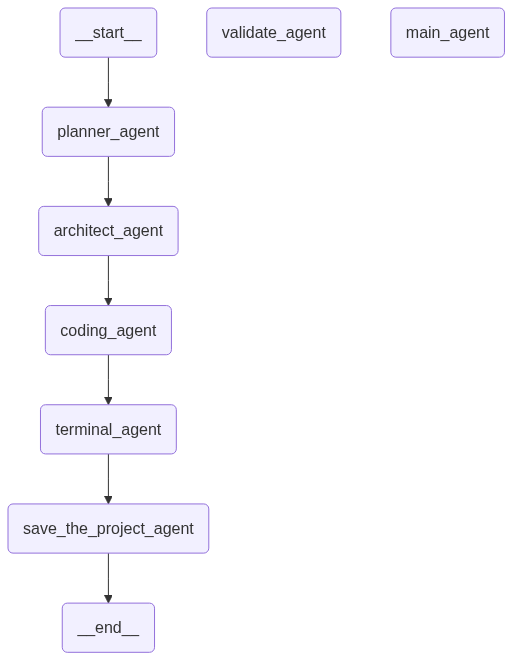

In [ ]:
builder.add_node("planner_agent",planner_agent)
builder.add_node("architect_agent",architect_agent)
builder.add_node("coding_agent",coding_agent)
builder.add_node("terminal_agent",)
builder.add_node("save_the_project_agent",save_node)
builder.add_node("validate_agent",validate_node)
builder.add_node("main_agent",run_pipeline)



builder.add_edge(START,"planner_agent")
builder.add_edge("planner_agent","architect_agent")
builder.add_edge("architect_agent","coding_agent")
builder.add_edge("coding_agent","terminal_agent")
builder.add_edge("terminal_agent","save_the_project_agent")
builder.add_edge("validate_agent","main_agent")
builder.add_edge("main_agent",END)

graph = builder.compile()


graph

In [22]:
graph.invoke({"messages": query})

KeyError: 'query'